# Second Pass analytics

After running the second pass of training with the following configuration:
```python
entropy = [0.0, 0.0025, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
iterations = 500
sgd_minibatch_size = 10
train_batch_size = 4000
```
We were able to get a good-enough result (reward >= 6)! 🎉

This notebook aims to dive deeper in the training process and prepare any visualizations we think is necessary for the final submission.

## Environment setup and dataset loading

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid')

In [18]:
data_path = Path('../logs_processed/second-pass/aggregated.csv')
df = pd.read_csv(data_path)

df.head()

,job_id,iteration,train_batch_size,sgd_minibatch_size,entropy,max_reward,is_target_reached,is_training_stable
0,0,500,4000,10,0.0000,5.78,False,True
1,1,500,4000,10,0.0500,4.17,False,True
2,2,500,4000,10,0.0025,6.32,True,True
3,3,500,4000,10,0.0400,4.82,False,True
4,4,500,4000,10,0.0200,6.39,True,True


## Basic exploration of the results

In [19]:
df[df['max_reward'] > 6].sort_values('max_reward', ascending=False)

,job_id,iteration,train_batch_size,sgd_minibatch_size,entropy,max_reward,is_target_reached,is_training_stable
7,7,500,4000,10,0.0100,6.41,True,True
4,4,500,4000,10,0.0200,6.39,True,True
2,2,500,4000,10,0.0025,6.32,True,True
6,6,500,4000,10,0.0050,6.08,True,True


This means that these entropies have been able to get an good enough reward:
- 0.01
- 0.02
- 0.0025
- 0.0050

We will exmaine these configurations more closely. But first, let's see a high level overview of the training progress.

In [20]:
df[df['is_training_stable'] == False]

,job_id,iteration,train_batch_size,sgd_minibatch_size,entropy,max_reward,is_target_reached,is_training_stable


This means that our hyperparameter selection has been stable enough that none of the training jobs has crashed!

## Reward distribution based on entropy

Bar chart showing:
- x-axis: entropy
- y-axis: max_reward
- horizontal line: reward = 6.0

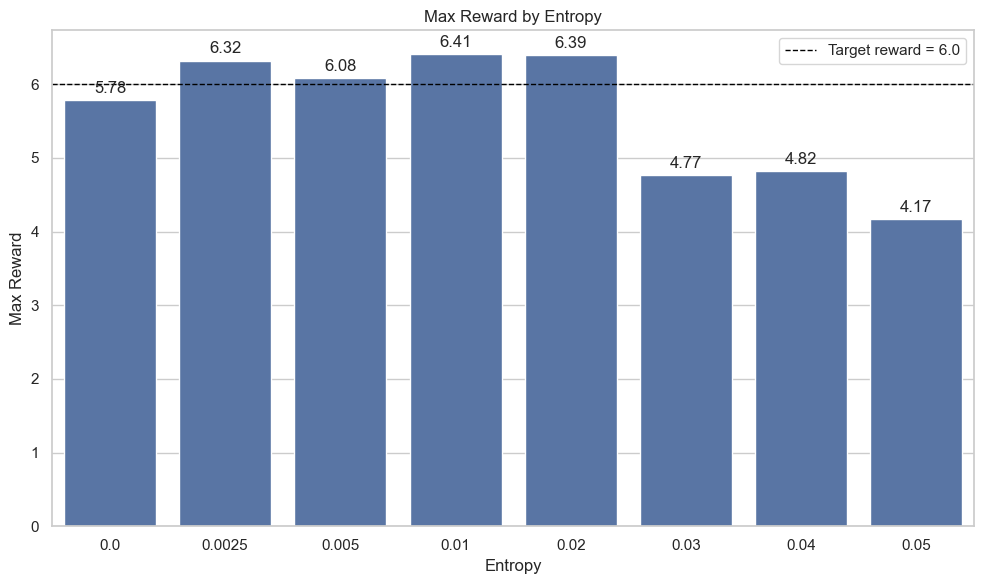

In [21]:
plot_data = df.sort_values('entropy')

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_data,
    x='entropy',
    y='max_reward',
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Max Reward by Entropy')
ax.set_xlabel('Entropy')
ax.set_ylabel('Max Reward')
ax.legend()
plt.tight_layout()
plt.show()

## Training progress overview

lineplot showing:
- x-axis: training progress
- Y-axis current reward
- horizontal line: reward = 6.0

### Entropy: 0.0025

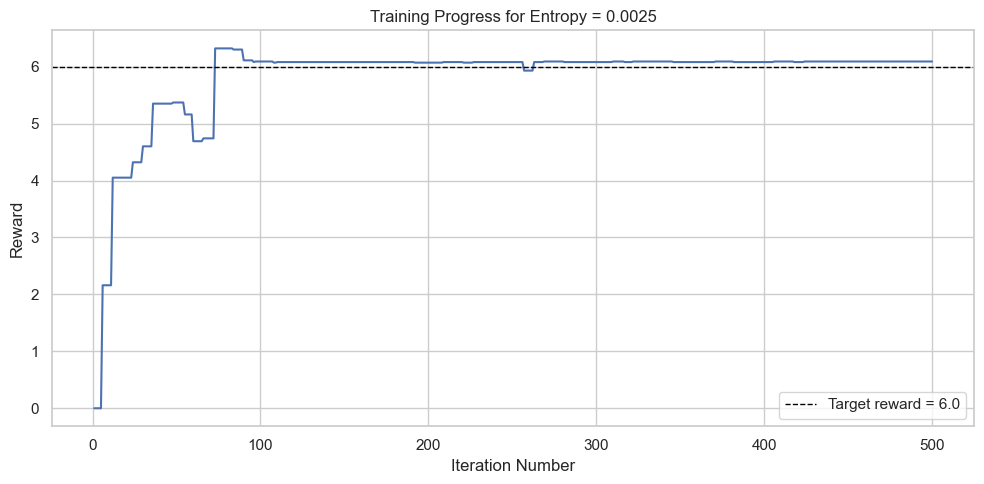

In [22]:
df_entropy_00025 = pd.read_csv('../logs_processed/second-pass/job_2_iter_500_batch_4000_sgd_10_entropy_0_0025.csv')

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=df_entropy_00025, x='iteration_number', y='reward')
ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Training Progress for Entropy = 0.0025')
ax.set_xlabel('Iteration Number')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
plt.show()

### Entropy: 0.005

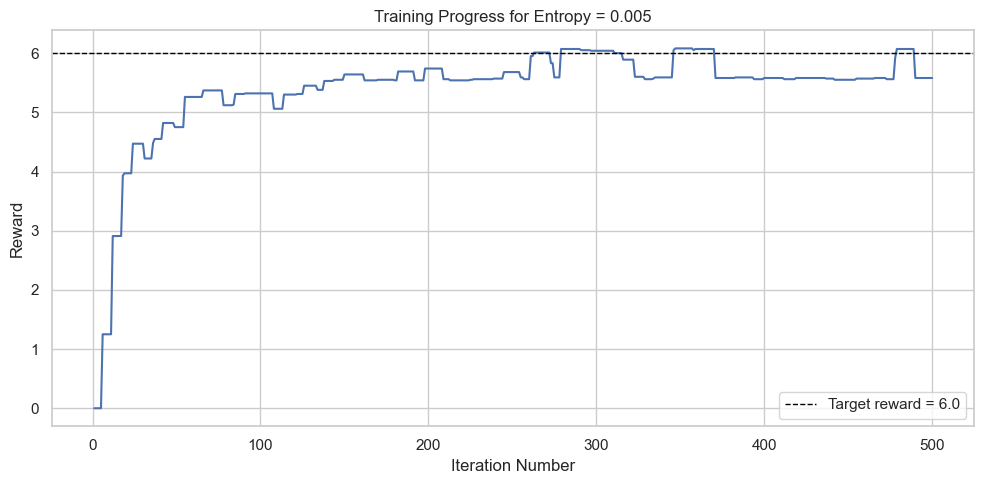

In [23]:
df_entropy_0005 = pd.read_csv('../logs_processed/second-pass/job_6_iter_500_batch_4000_sgd_10_entropy_0_005.csv')

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=df_entropy_0005, x='iteration_number', y='reward')
ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Training Progress for Entropy = 0.005')
ax.set_xlabel('Iteration Number')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
plt.show()

### Entropy: 0.01

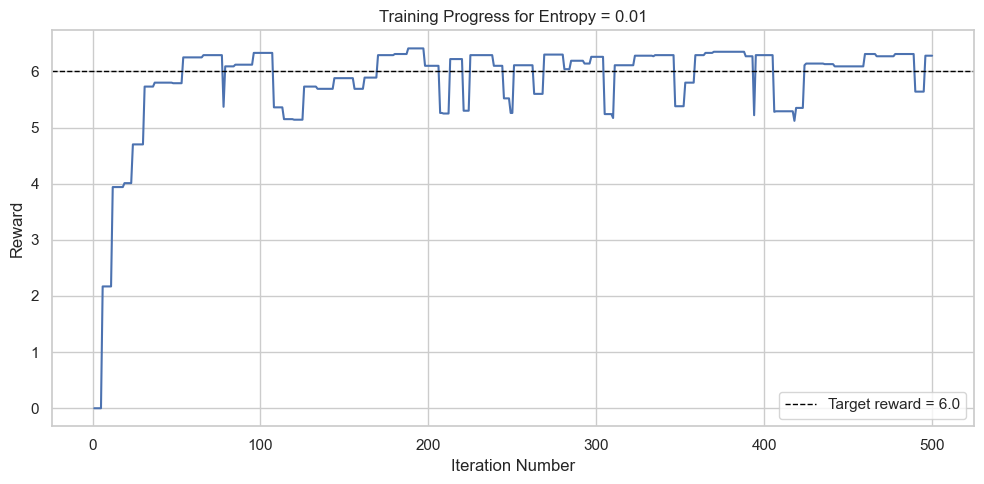

In [24]:
df_entropy_001 = pd.read_csv('../logs_processed/second-pass/job_7_iter_500_batch_4000_sgd_10_entropy_0_01.csv')

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=df_entropy_001, x='iteration_number', y='reward')
ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Training Progress for Entropy = 0.01')
ax.set_xlabel('Iteration Number')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
plt.show()

### Entropy: 0.02

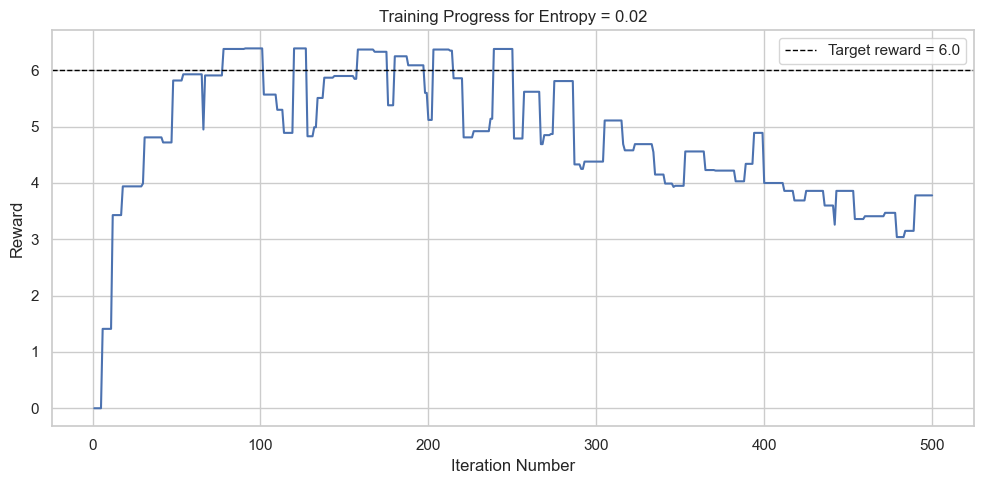

In [25]:
df_entropy_002 = pd.read_csv('../logs_processed/second-pass/job_4_iter_500_batch_4000_sgd_10_entropy_0_02.csv')

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=df_entropy_002, x='iteration_number', y='reward')
ax.axhline(6.0, color='black', linestyle='--', linewidth=1, label='Target reward = 6.0')
ax.set_title('Training Progress for Entropy = 0.02')
ax.set_xlabel('Iteration Number')
ax.set_ylabel('Reward')
ax.legend()
plt.tight_layout()
plt.show()

These visualizations show that although `entropy=0.02` has had the best `max_reward` through the training progress, the behavior of the agent with `entropy=0.0025` has been much more stable than its counterparts. Basically, the `entropy=0.0025` agent shows an almost-constant higher than 6 behavior which make it favourable compared to the small reward gain we might get from the `entropy=0.02` or `entropy=0.01` agent.

## Final remarks

It seems like with the change of parameters compared to the first-pass the training has become more stable. There have been several trained agents with cumulative reward higher than 6, but it seems like the agent with `entropy=0.0025` has demonstrated a much more stable behavior through the learning process.

Unfortunately, we are out of time for this assignment; however, if we had time we would start mixing entropies: 0.0025, 0.01, 0.02 with higher iteration, sgd-minibatch-size, train_batch_size to see if we can achieve a higher cumulative result.